# SIG720 Task 1P - Part B: Data Wrangling and Exploratory Analysis

This notebook performs the practical data wrangling and exploratory analysis tasks required for the City of Melbourne Microclimate sensors dataset.

### Loading Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import MinMaxScaler

In [2]:
#additional libraries
import folium

## Exploratory Data Analysis

### Loading Data & Initial Exploration

In [3]:
df = pd.read_csv('../Datasets/microclimate-sensors-data.csv')
df.head()

,Device_id,Time,SensorLocation,LatLong,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise
0,ICTMicroclimate-08,2026-04-29T01:25:15+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,220.0,314.0,0.0,0.5,2.5,16.7,79.9,1026.1,10.0,12.0,58.7
1,ICTMicroclimate-08,2026-04-28T14:38:50+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,283.0,353.0,0.0,0.9,2.6,21.9,61.5,1021.5,27.0,32.0,75.6
2,ICTMicroclimate-08,2026-04-28T15:08:52+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,310.0,314.0,0.0,0.2,1.9,21.6,61.1,1021.3,26.0,29.0,69.2
3,ICTMicroclimate-10,2026-04-28T20:19:41+10:00,1 Treasury Place,"-37.8128595, 144.9745395",277.0,324.0,352.0,0.3,0.8,1.3,19.7,57.4,1018.4,39.0,49.0,61.9
4,ICTMicroclimate-08,2026-04-28T23:55:03+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,281.0,354.0,0.0,0.3,2.5,17.3,76.2,1025.5,10.0,12.0,79.4


In [4]:
data = df.copy()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940959 entries, 0 to 940958
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Device_id             940959 non-null  object 
 1   Time                  940959 non-null  object 
 2   SensorLocation        940959 non-null  object 
 3   LatLong               940959 non-null  object 
 4   MinimumWindDirection  801952 non-null  float64
 5   AverageWindDirection  925229 non-null  float64
 6   MaximumWindDirection  801942 non-null  float64
 7   MinimumWindSpeed      801942 non-null  float64
 8   AverageWindSpeed      925227 non-null  float64
 9   GustWindSpeed         801942 non-null  float64
 10  AirTemperature        925227 non-null  float64
 11  RelativeHumidity      925227 non-null  float64
 12  AtmosphericPressure   925227 non-null  float64
 13  PM25                  863611 non-null  float64
 14  PM10                  863611 non-null  float64
 15  

- 940,959 records
- all numerical values, lat and long are seen as object (perhaps required conversion), there is a timestamp per record (Sensor reading)
- Some features do have null or na values (requires investigation below)

In [6]:
#I would like to see the data range
print("date range is between: ", data['Time'].min(), " and ", data['Time'].max())

date range is between:  2022-05-31T10:11:28+10:00  and  2026-06-27T19:10:30+10:00


**--> Approx 4 years of data**

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
MinimumWindDirection,801952.0,23.935393,61.892055,0.0,0.0,0.0,0.0,359.000000
AverageWindDirection,925229.0,165.712491,126.162036,0.0,40.0,159.0,300.0,359.000000
MaximumWindDirection,801942.0,294.794842,98.458909,0.0,247.0,351.0,357.0,360.000000
MinimumWindSpeed,801942.0,0.229892,0.569302,0.0,0.0,0.0,0.1,11.600000
AverageWindSpeed,925227.0,0.995286,0.936895,0.0,0.3,0.7,1.4,11.200000
GustWindSpeed,801942.0,3.144411,2.507063,0.0,1.3,2.5,4.4,52.500000
AirTemperature,925227.0,16.550796,5.520409,-0.8,12.7,16.0,19.5,45.400002
RelativeHumidity,925227.0,68.700242,17.613534,2.5,57.1,70.1,81.6,99.800003
AtmosphericPressure,925227.0,1014.199243,9.894435,894.7,1008.7,1014.4,1020.3,1042.900000
PM25,863611.0,6.810075,29.497860,0.0,1.0,3.0,7.0,3414.000000


In [8]:
#A quick fix to splot lat and long values
data[['Lat','Long']] = data['LatLong'].str.split(',', expand=True)
data.head()

,Device_id,Time,SensorLocation,LatLong,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise,Lat,Long
0,ICTMicroclimate-08,2026-04-29T01:25:15+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,220.0,314.0,0.0,0.5,2.5,16.7,79.9,1026.1,10.0,12.0,58.7,-37.8184515,144.9678474
1,ICTMicroclimate-08,2026-04-28T14:38:50+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,283.0,353.0,0.0,0.9,2.6,21.9,61.5,1021.5,27.0,32.0,75.6,-37.8184515,144.9678474
2,ICTMicroclimate-08,2026-04-28T15:08:52+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,310.0,314.0,0.0,0.2,1.9,21.6,61.1,1021.3,26.0,29.0,69.2,-37.8184515,144.9678474
3,ICTMicroclimate-10,2026-04-28T20:19:41+10:00,1 Treasury Place,"-37.8128595, 144.9745395",277.0,324.0,352.0,0.3,0.8,1.3,19.7,57.4,1018.4,39.0,49.0,61.9,-37.8128595,144.9745395
4,ICTMicroclimate-08,2026-04-28T23:55:03+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,281.0,354.0,0.0,0.3,2.5,17.3,76.2,1025.5,10.0,12.0,79.4,-37.8184515,144.9678474


In [9]:
data.drop('LatLong', axis=1, inplace=True)

In [10]:
# Convert both columns to numeric at once
data[['Lat', 'Long']] = data[['Lat', 'Long']].apply(pd.to_numeric, errors='coerce')

In [11]:
#applying this on a random sample of 500 observations to avoid long runs
sample_df = data.sample(500, random_state=42)

m = folium.Map(
    location=[sample_df["Lat"].mean(), data["Long"].mean()],
    zoom_start=12
)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row["Lat"], row["Long"]],
        radius=3,
        fill=True,
        fillcolor='#ff3300',
        color='#ff3300',
    ).add_to(m)

m

In [12]:
#from the 500 samples we see few dots on the map which means many readngs are from same location (same monitoring station or sensor)
sample_df[["Lat", "Long"]].nunique()

Lat     12
Long    12
dtype: int64

In [13]:
sample_df[["Lat", "Long"]].drop_duplicates().shape

(12, 2)

**and we can see 12 marked locations on the map which seems that our data is mostly out of 12 sensors! Located around Melbourne center**

### Data Quality Assessment

**1. Missing Values Check**

In [14]:
data.isna().sum()

Device_id                    0
Time                         0
SensorLocation               0
MinimumWindDirection    139007
AverageWindDirection     15730
MaximumWindDirection    139017
MinimumWindSpeed        139017
AverageWindSpeed         15732
GustWindSpeed           139017
AirTemperature           15732
RelativeHumidity         15732
AtmosphericPressure      15732
PM25                     77348
PM10                     77348
Noise                    77348
Lat                          0
Long                         0
dtype: int64

In [15]:
#getting percentages of those nulls
round(data.isnull().sum()/data.shape[0]*100,2).sort_values(ascending=False)

MinimumWindDirection    14.77
MinimumWindSpeed        14.77
GustWindSpeed           14.77
MaximumWindDirection    14.77
PM10                     8.22
PM25                     8.22
Noise                    8.22
AtmosphericPressure      1.67
AverageWindDirection     1.67
AverageWindSpeed         1.67
RelativeHumidity         1.67
AirTemperature           1.67
Device_id                0.00
SensorLocation           0.00
Time                     0.00
Lat                      0.00
Long                     0.00
dtype: float64

**It does not seem random to have all wind measurements in certain records missing and at the exact amount 14.7%, which means that possible some sensors or some cases are not reading wind speed (for any reason) - same applies for some pollutants and noise measurements**

**2. Block Missingness Validation**

A validation check of **Sensors**

In [16]:
data[data["MinimumWindDirection"].isnull()][
    ["Time", "Device_id", "SensorLocation", "MinimumWindDirection", 
     "MinimumWindSpeed", "GustWindSpeed", "MaximumWindDirection"]
].head()

,Time,Device_id,SensorLocation,MinimumWindDirection,MinimumWindSpeed,GustWindSpeed,MaximumWindDirection
333,2026-04-29T09:23:57+10:00,ICTMicroclimate-01,Birrarung Marr Park - Pole 1131,NaN,NaN,NaN,NaN
334,2026-04-29T10:54:01+10:00,ICTMicroclimate-01,Birrarung Marr Park - Pole 1131,NaN,NaN,NaN,NaN
335,2026-04-28T20:38:38+10:00,ICTMicroclimate-01,Birrarung Marr Park - Pole 1131,NaN,NaN,NaN,NaN
336,2026-04-29T08:53:57+10:00,ICTMicroclimate-01,Birrarung Marr Park - Pole 1131,NaN,NaN,NaN,NaN
337,2026-04-29T11:09:02+10:00,ICTMicroclimate-01,Birrarung Marr Park - Pole 1131,NaN,NaN,NaN,NaN


In [17]:
wind_missing_cols = [
    "MinimumWindDirection",
    "MinimumWindSpeed",
    "GustWindSpeed",
    "MaximumWindDirection"
]

data[wind_missing_cols].isnull().all(axis=1).mean() * 100

np.float64(14.772907214873337)

In [18]:
data.loc[
    data[wind_missing_cols].isnull().all(axis=1),
    ["Device_id", "SensorLocation"]
].value_counts()

Device_id           SensorLocation                                                                  
ICTMicroclimate-01  Birrarung Marr Park - Pole 1131                                                     137818
ICTMicroclimate-02  101 Collins St L11 Rooftop                                                             643
ICTMicroclimate-11  1 Treasury Place                                                                       152
ICTMicroclimate-10  1 Treasury Place                                                                       136
ICTMicroclimate-03  CH1 rooftop                                                                            100
ICTMicroclimate-05  Enterprize Park - Pole ID: COM1667                                                      48
ICTMicroclimate-07  Tram Stop 7C – Melbourne Tennis Centre Precinct – Rod Laver Arena                       29
ICTMicroclimate-09  SkyFarm (Jeff’s Shed). Rooftop - Melbourne Conference & Exhibition Centre (MCEC)        26
ICTMicrocli

In [19]:
pollution_noise_cols = ["PM10", "PM25", "Noise"]

data[pollution_noise_cols].isnull().all(axis=1).mean() * 100

np.float64(8.220124362485507)

**Conclusion - 01**<br>The wind variables show block missingness, with all four wind-related fields missing together in around 14.77% of rows. This missingness is highly concentrated in ICTMicroclimate-01 at Birrarung Marr Park - Pole 1131, suggesting a sensor/location-specific data availability issue rather than random missing values.

**3. checking Duplicates**

In [20]:
data.duplicated().sum()

np.int64(0)

**4. Data Types Check**

In [21]:
data["Time"].head()
data["Time"].dtype

dtype('O')

In [22]:
data["Time"] = pd.to_datetime(data["Time"], errors="coerce", utc=True)

In [23]:
data["Time"].dtype

datetime64[ns, UTC]

In [24]:
data.nunique().sort_values(ascending=False)

Time                    935478
RelativeHumidity          1566
Noise                     1234
AtmosphericPressure       1208
AirTemperature             609
PM25                       536
PM10                       531
MaximumWindDirection       361
MinimumWindDirection       360
AverageWindDirection       360
GustWindSpeed              316
AverageWindSpeed           108
MinimumWindSpeed           106
Device_id                   12
Lat                         12
Long                        12
SensorLocation              11
dtype: int64

In [25]:
data[["Device_id", "SensorLocation", "Lat", "Long"]].nunique()

Device_id         12
SensorLocation    11
Lat               12
Long              12
dtype: int64

In [26]:
#checking for any impossible values (which does not make sense)
print((data["PM25"] < 0).sum())
print((data["PM10"] < 0).sum())
print((data["AverageWindSpeed"] < 0).sum())
print((data["AverageWindDirection"].between(0, 360)).value_counts())
print((data["RelativeHumidity"].between(0, 100)).value_counts())

0
0
0
AverageWindDirection
True     925229
False     15730
Name: count, dtype: int64
RelativeHumidity
True     925227
False     15732
Name: count, dtype: int64


I want to double check if those weird observations of AverageWindDirection and RelativeHumidity are due to zero values or actually wrong recordings

In [27]:
print("AverageWindDirection validation:")
print(data["AverageWindDirection"].dropna().between(0, 360).value_counts())

print("\nRelativeHumidity validation:")
print(data["RelativeHumidity"].dropna().between(0, 100).value_counts())

AverageWindDirection validation:
AverageWindDirection
True    925229
Name: count, dtype: int64

RelativeHumidity validation:
RelativeHumidity
True    925227
Name: count, dtype: int64


In [28]:
data.loc[
    data[["PM10", "PM25", "Noise"]].isnull().all(axis=1),
    ["Device_id", "SensorLocation"]
].value_counts()

Device_id           SensorLocation                                                                  
aws5-0999           Royal Park Asset ID: COM2707                                                        61618
ICTMicroclimate-01  Birrarung Marr Park - Pole 1131                                                     14533
ICTMicroclimate-02  101 Collins St L11 Rooftop                                                            643
ICTMicroclimate-11  1 Treasury Place                                                                      152
ICTMicroclimate-10  1 Treasury Place                                                                      146
ICTMicroclimate-03  CH1 rooftop                                                                           100
ICTMicroclimate-05  Enterprize Park - Pole ID: COM1667                                                     48
ICTMicroclimate-07  Tram Stop 7C – Melbourne Tennis Centre Precinct – Rod Laver Arena                      29
ICTMicroclimate-09 

In [29]:
data["Time"].isnull().sum()

np.int64(0)

**Conclusion - 02**

No duplicate rows were identified. After excluding missing values, all observed values for AverageWindDirection and RelativeHumidity fall within their valid expected ranges. Therefore, the earlier invalid counts were caused by missing values being treated as False in the validation check, not by out-of-range sensor readings. I will proceed next with outliers checks and skewness analysis before we do some cleaning and then univariate and bivariate analysis

## Univariate Analysis

### Distribution Check

In [30]:
numeric_cols = data.select_dtypes(include="number").columns.tolist()

# I want to Exclude location coordinates from distribution/skewness checks
measurement_cols = [col for col in numeric_cols if col not in ["Lat", "Long"]]

measurement_cols

['MinimumWindDirection',
 'AverageWindDirection',
 'MaximumWindDirection',
 'MinimumWindSpeed',
 'AverageWindSpeed',
 'GustWindSpeed',
 'AirTemperature',
 'RelativeHumidity',
 'AtmosphericPressure',
 'PM25',
 'PM10',
 'Noise']

In [31]:
skewness_table = (
    data[measurement_cols]
    .skew()
    .sort_values(ascending=False)
    .reset_index()
)

skewness_table.columns = ["Feature", "Skewness"]

skewness_table

,Feature,Skewness
0,PM25,81.312767
1,PM10,77.513914
2,MinimumWindSpeed,4.066910
3,MinimumWindDirection,2.878747
4,AverageWindSpeed,1.822817
5,GustWindSpeed,1.652729
6,AirTemperature,0.776207
7,Noise,0.309524
8,AverageWindDirection,0.150296
9,RelativeHumidity,-0.433861


* Right Skewed:
* PM25 = 81.31
* PM10 = 77.51
<br>These two features are highly right-skewed - we need to look into that later on in our analysis
<br>Other features like MinimumSpeed, MinimumWindDirection, AverageWindSpeed and GustWindSpeed also are right-skewed
* Left Skewed:
* MaximumWindDirection = -1.57
* AtmosphericPressure = -3.09
<br> There are other features with low or moderate skeness - all is shown in the distribution plots below

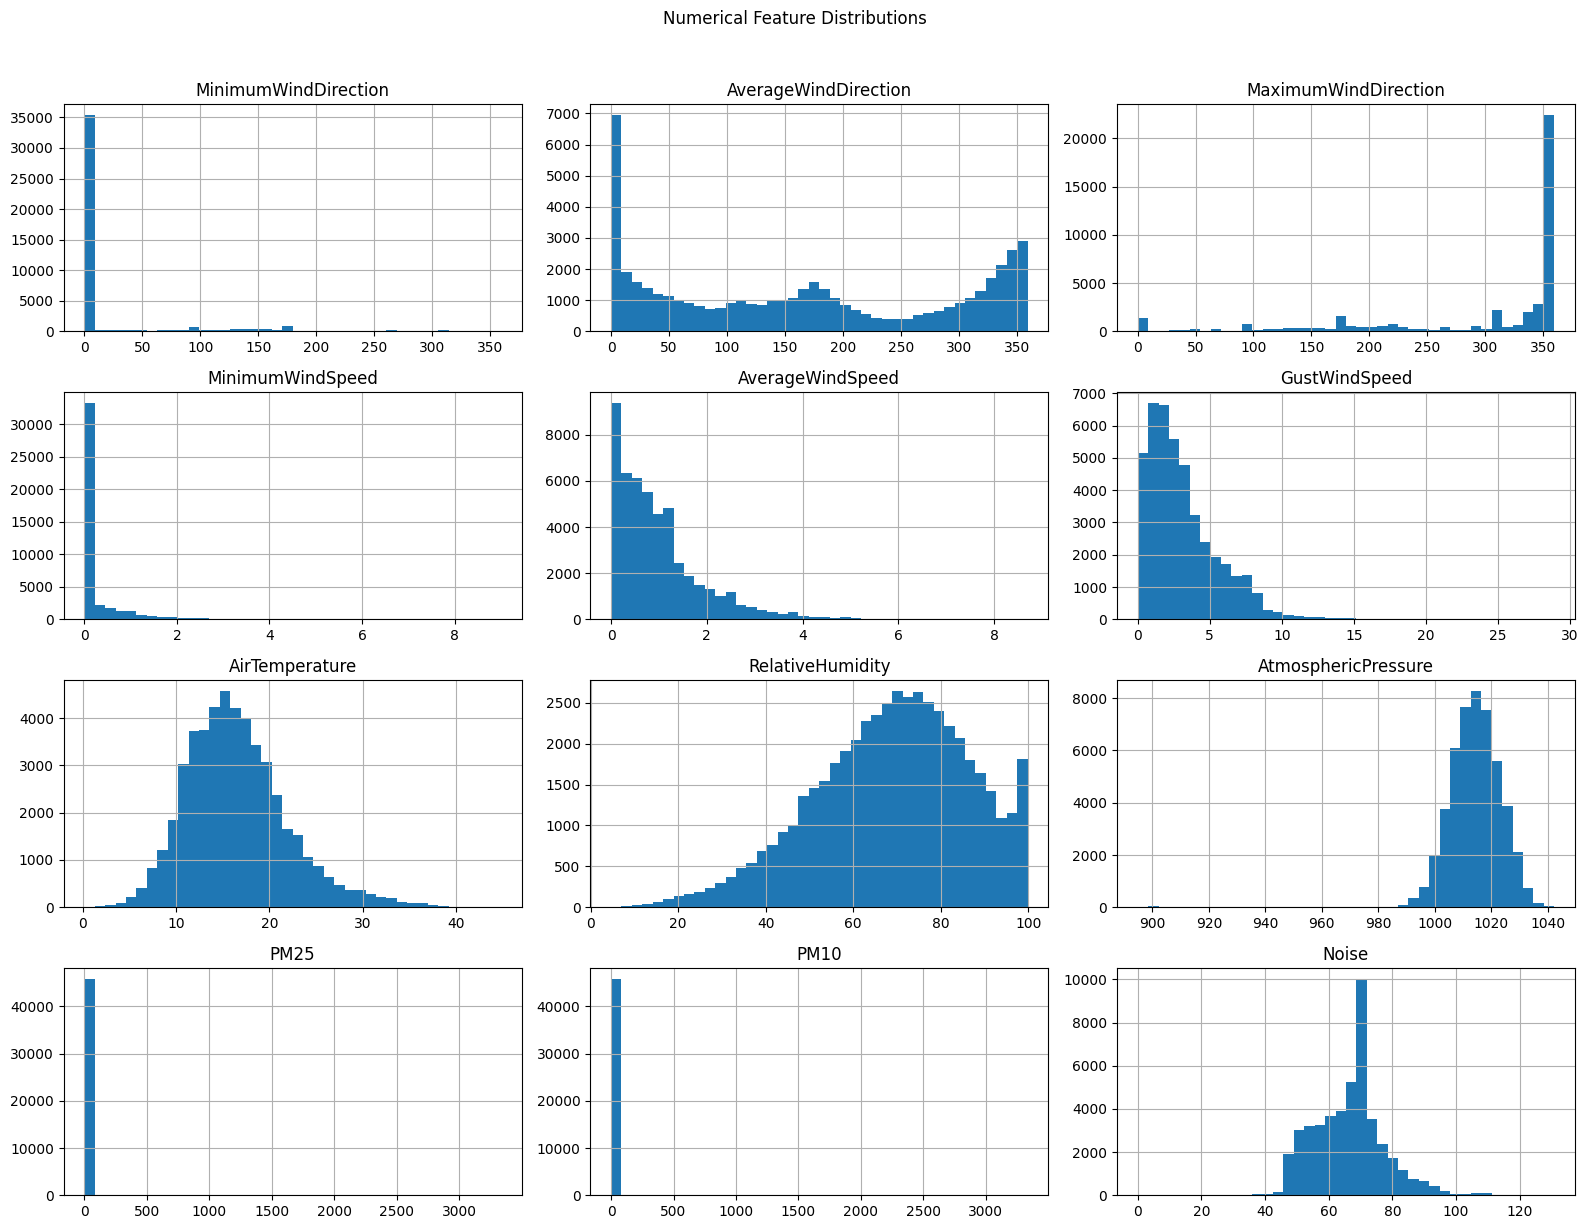

In [33]:
plot_data = data[measurement_cols].sample(
    n=min(50000, len(data)), 
    random_state=42
)

plot_data.hist(
    bins=40,
    figsize=(16, 12)
)

plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

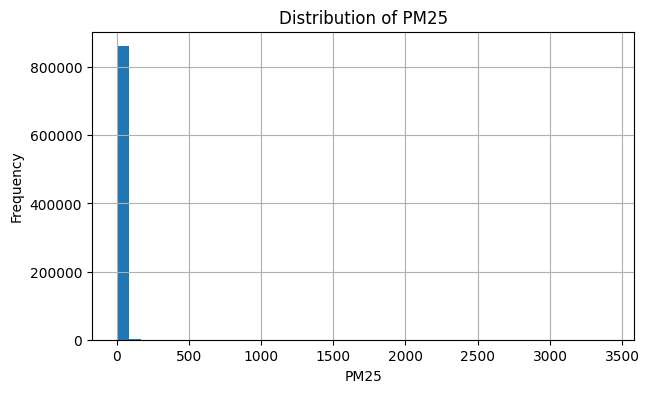

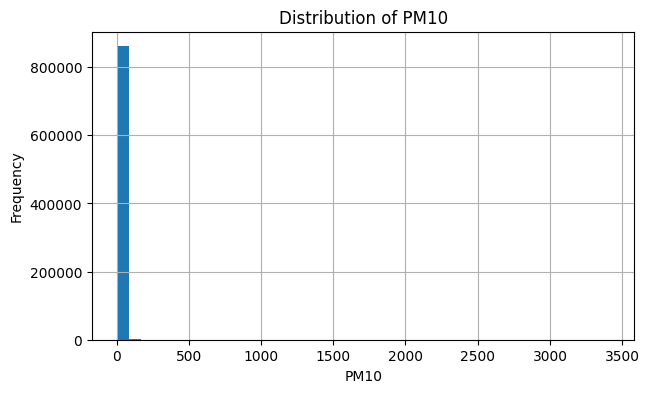

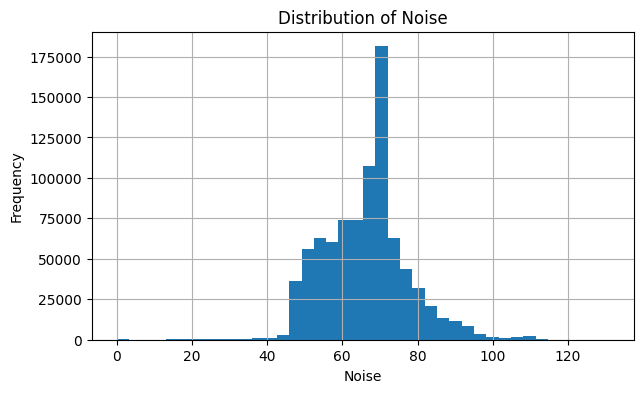

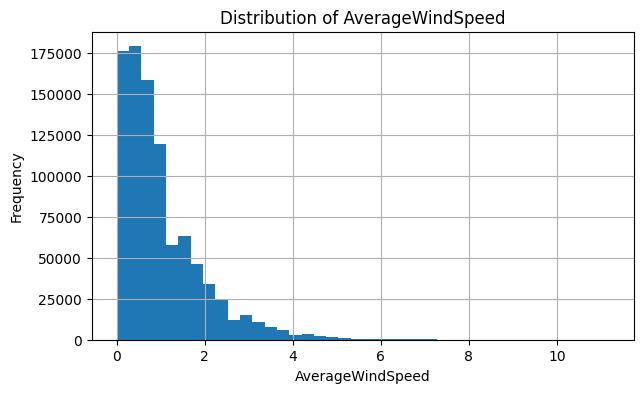

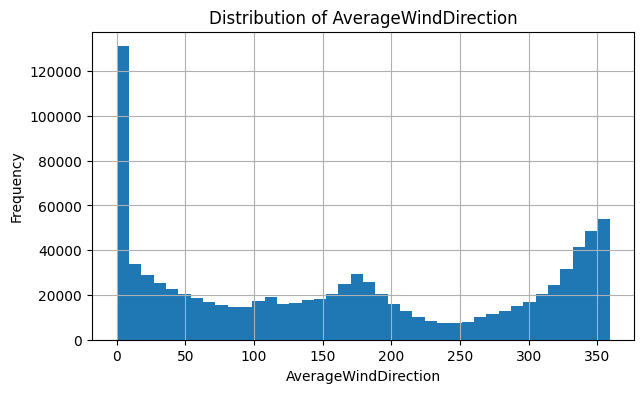

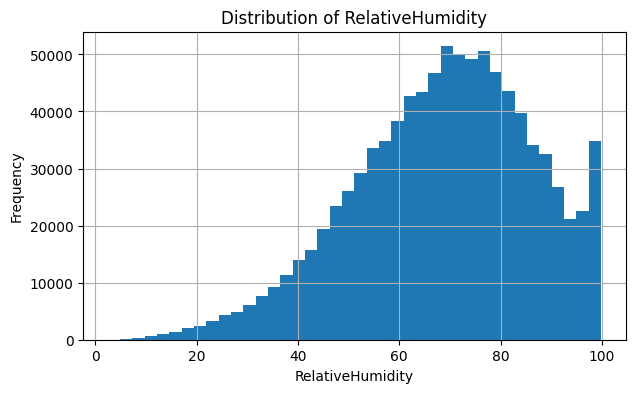

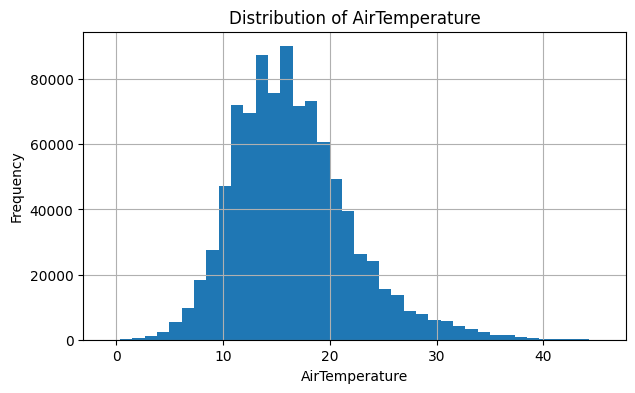

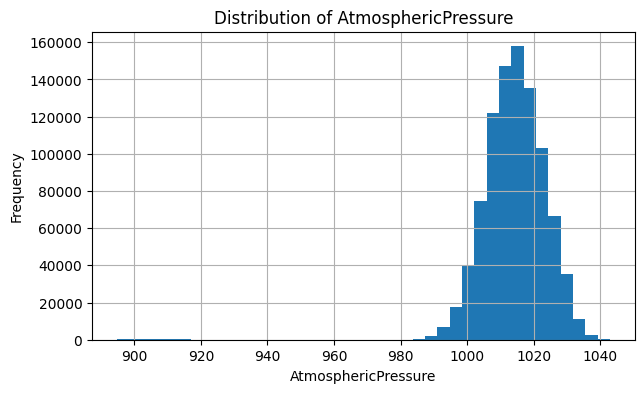

In [34]:
important_features = [
    "PM25",
    "PM10",
    "Noise",
    "AverageWindSpeed",
    "AverageWindDirection",
    "RelativeHumidity",
    "AirTemperature",
    "AtmosphericPressure"
]

for col in important_features:
    if col in data.columns:
        plt.figure(figsize=(7, 4))
        data[col].dropna().hist(bins=40)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

**Conclusion - 03**<br>
The raw numerical distributions show different patterns across the sensor measurements. `PM25` and `PM10` are extremely right-skewed, with most observations concentrated near low values and a small number of very large readings. This explains their very high skewness values and suggests the presence of rare pollution spikes or possible extreme sensor readings.

Wind speed variables such as `MinimumWindSpeed`, `AverageWindSpeed`, and `GustWindSpeed` are also right-skewed. Most wind speed values are low to moderate, while only a smaller number of observations show high wind speeds. This pattern is expected in environmental sensor data, but it may affect the choice of imputation method later.

`AirTemperature` appears moderately right-skewed, while `Noise` is closer to a roughly symmetric distribution with most values concentrated around the middle range. `RelativeHumidity` is slightly left-skewed, with many values concentrated at higher humidity levels. `AtmosphericPressure` is also left-skewed, with most observations around the higher pressure range and some lower values pulling the distribution left.

The wind direction variables should be interpreted carefully because direction is circular. For example, 0 degrees and 360 degrees represent nearly the same direction, so normal skewness interpretation is less meaningful for these features. These variables may be better transformed into directional categories later.

Overall, the distribution check suggests that median-based imputation may be more appropriate for highly skewed variables such as `PM25`, `PM10`, and wind speed features, while further outlier checks are needed before deciding whether any extreme values should be treated or retained.

### Outlier Check

In [36]:
# A function to plot the boxplots to be able to detect outliers values
def plot_boxplots(df, columns=None, exclude_cols=None, sample_size=50000, ncols=3):
    """
    Plot boxplots for selected numerical columns.
    
    Parameters:
    df: pandas DataFrame
    columns: list of columns to plot. If None, all numeric columns are used.
    exclude_cols: columns to exclude from plotting.
    sample_size: sample size used for plotting large datasets.
    ncols: number of plots per row.
    """
    
    import math
    import matplotlib.pyplot as plt
    
    if exclude_cols is None:
        exclude_cols = []
    
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()
    
    columns = [col for col in columns if col not in exclude_cols]
    
    plot_df = df[columns].dropna()
    
    if len(plot_df) > sample_size:
        plot_df = plot_df.sample(sample_size, random_state=42)
    
    n_features = len(columns)
    nrows = math.ceil(n_features / ncols)
    
    plt.figure(figsize=(5 * ncols, 4 * nrows))
    
    for i, col in enumerate(columns, 1):
        plt.subplot(nrows, ncols, i)
        plt.boxplot(plot_df[col].dropna(), vert=True)
        plt.title(col)
        plt.ylabel("Value")
    
    plt.tight_layout()
    plt.show()

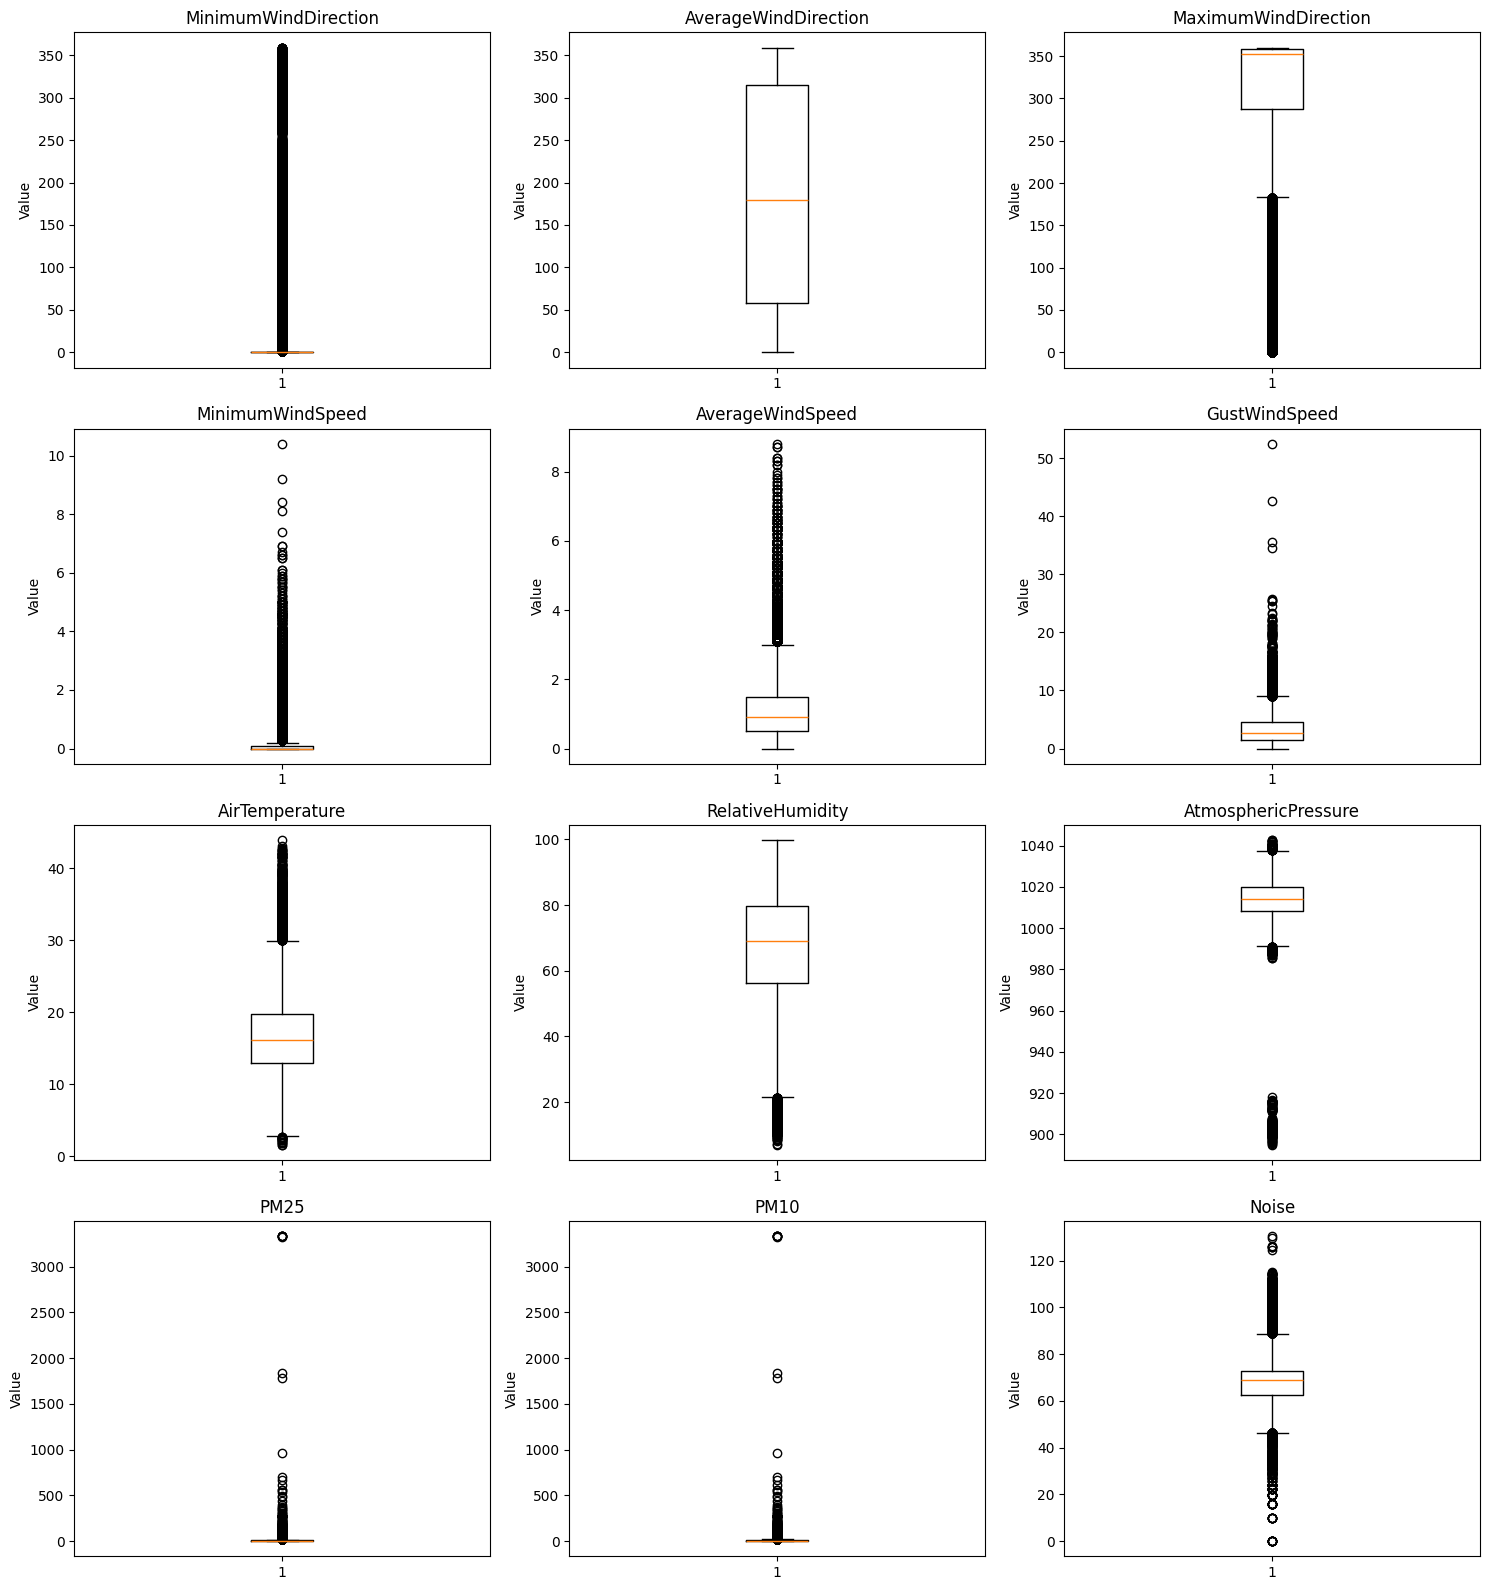

In [37]:
# making the plots
plot_boxplots(
    data,
    columns=measurement_cols,
    sample_size=50000,
    ncols=3
)

**conclusion - 04**

The boxplots show that several numerical variables contain values outside the IQR-based whisker range. The strongest outlier patterns appear in `PM25` and `PM10`, where most values are concentrated near the lower range, but a small number of observations are extremely high. This is consistent with the earlier skewness results and suggests rare pollution spikes or possible extreme sensor readings.

Wind speed variables also show many high-end outliers, especially `AverageWindSpeed`, `GustWindSpeed`, and `MinimumWindSpeed`. This indicates that most wind readings are relatively low, while occasional high wind events occur. These values may be valid environmental events, so they should not be removed automatically without further justification.

`AirTemperature`, `RelativeHumidity`, `AtmosphericPressure`, and `Noise` also show some observations outside the whisker range, but their distributions appear more compact compared with PM and wind speed variables. These may represent unusual but plausible environmental conditions.

The wind direction variables require careful interpretation because direction is circular. Values near 0 and 360 degrees represent similar directions, so boxplot-based outlier interpretation is less meaningful for these columns. These features may be better handled later through directional categorisation rather than traditional outlier treatment.

Overall, the boxplots confirm that the dataset contains several extreme values, particularly in pollution and wind speed measurements. These should be investigated using numerical outlier summaries before deciding whether to retain, cap, transform, or leave them unchanged.

In [38]:
def iqr_outlier_summary(df, columns=None, exclude_cols=None):
    """
    Create an IQR-based outlier summary table for numerical columns.
    """
    
    if exclude_cols is None:
        exclude_cols = []
    
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()
    
    columns = [col for col in columns if col not in exclude_cols]
    
    summary = []
    
    for col in columns:
        series = df[col].dropna()
        
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
        outlier_percentage = round((outlier_count / len(series)) * 100, 2)
        
        summary.append({
            "Feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage": outlier_percentage
        })
    
    return pd.DataFrame(summary).sort_values("Outlier_Percentage", ascending=False)

In [39]:
outlier_summary = iqr_outlier_summary(
    data,
    columns=measurement_cols
)

outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
3,MinimumWindSpeed,0.0,0.1,0.1,-0.15,0.25,175778,21.92
0,MinimumWindDirection,0.0,0.0,0.0,0.00,0.00,147448,18.39
10,PM10,3.0,9.0,6.0,-6.00,18.00,88840,10.29
9,PM25,1.0,7.0,6.0,-8.00,16.00,82063,9.50
2,MaximumWindDirection,247.0,357.0,110.0,82.00,522.00,43245,5.39
4,AverageWindSpeed,0.3,1.4,1.1,-1.35,3.05,37978,4.10
11,Noise,58.6,71.7,13.1,38.95,91.35,23116,2.68
6,AirTemperature,12.7,19.5,6.8,2.50,29.70,24635,2.66
5,GustWindSpeed,1.3,4.4,3.1,-3.35,9.05,17854,2.23
7,RelativeHumidity,57.1,81.6,24.5,20.35,118.35,6177,0.67


**Conclusion - 05**

The IQR-based outlier table shows that the highest proportion of potential outliers appears in `MinimumWindSpeed`, `MinimumWindDirection`, `PM10`, `PM25`, and `MaximumWindDirection`. However, these results should be interpreted carefully because not all IQR outliers are necessarily incorrect data points.

- `MinimumWindSpeed` has the highest outlier percentage at about 21.92%. This is likely because most minimum wind speed values are very close to zero, making the IQR very small. As a result, even slightly higher values are flagged as outliers. These may still be valid readings rather than errors.

- `MinimumWindDirection` has an IQR of 0, which means many values are concentrated at the same value, likely 0 degrees. Because of this, the IQR method becomes too strict and flags many other direction values as outliers. Since wind direction is circular, this column should not be judged using normal numerical outlier logic.

- `PM10` and `PM25` have high outlier percentages, around 10.29% and 9.50%. This supports the earlier histogram and skewness results, where both features showed strong right-skewness. These high readings may represent pollution spikes, unusual environmental events, or sensor anomalies. Domain knowledge would be needed to confirm whether they are valid or erroneous.

- `MaximumWindDirection` also shows outliers, but this feature is another circular direction variable. Values near 0 and 360 degrees are directionally the same (circular nature here), so IQR-based outlier detection is not fully appropriate.

- Other variables such as `AverageWindSpeed`, `Noise`, `AirTemperature`, `GustWindSpeed`, `RelativeHumidity`, and `AtmosphericPressure` show lower outlier percentages. These may represent unusual but plausible environmental conditions.

Overall, the outlier check suggests that the most problematic features are pollution-related variables and some wind-related variables. However, automatic removal is not recommended at this stage because extreme values in environmental data may be meaningful real-world events.

Possible next steps:
- Investigate the extreme `PM25` and `PM10` trends across time and aim to make any sense.
- Check whether high pollution values are concentrated in specific sensors or time periods.
- Treat wind direction variables separately by converting them into compass categories instead of applying normal outlier treatment.
- Consider median imputation for highly skewed variables because the mean may be affected by extreme values.
- Decide later whether to retain, cap, or transform extreme pollution and wind speed values depending on the modelling purpose and available domain knowledge.

**Visualizing `PM2.5` and `PM10` trends**

In [40]:
# making a copy for time-series plotting
ts_data = data.copy()

# Keeping only valid time and PM records
ts_pm = ts_data[["Time", "PM25", "PM10"]].dropna()

# Sorting by time
ts_pm = ts_pm.sort_values("Time")

# Setting Time as index
ts_pm = ts_pm.set_index("Time")

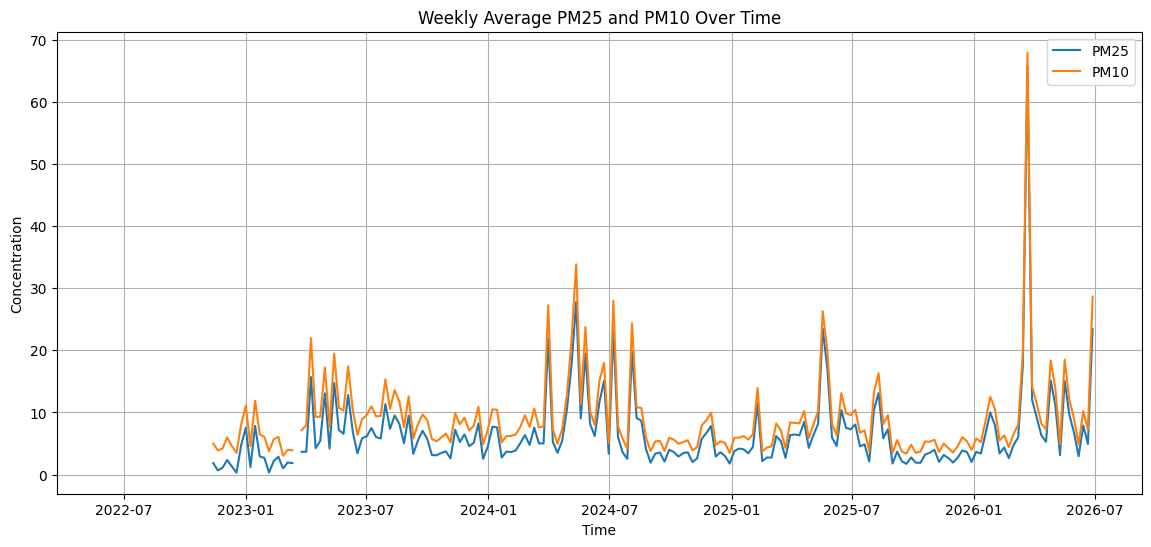

In [42]:
# Weekly average to make the trend readable and easy to understand
pm_weekly = ts_pm[["PM25", "PM10"]].resample("W").mean()

plt.figure(figsize=(14, 6))

plt.plot(pm_weekly.index, pm_weekly["PM25"], label="PM25")
plt.plot(pm_weekly.index, pm_weekly["PM10"], label="PM10")

plt.title("Weekly Average PM25 and PM10 Over Time")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.show()

**Conclusion - 06: PM25 and PM10 Weekly Trend Observation**

The weekly average time-series plot shows that `PM25` and `PM10` generally move together over time, which suggests a positive relationship between the two particulate matter variables. `PM10` is usually higher than `PM25`, which is expected because PM10 includes larger airborne particles in addition to finer particles.

The plot also shows several clear spikes across the dataset, with the largest spike appearing in 2026. These spikes help explain the earlier findings of extreme right-skewness and high IQR-based outlier percentages for both `PM25` and `PM10`. However, the spikes should not automatically be treated as errors because they may represent real environmental events, temporary pollution episodes, or sensor/location-specific conditions.

The very large 2026 spike should be investigated further before deciding how to handle it. The next step is to check whether this spike is caused by:
- a small number of extreme readings,
- one specific sensor/location,
- a short time period,
- or a broader increase across multiple sensors.

If the weekly mean is high but the weekly median remains normal, then the spike is likely driven by a few extreme values. If both mean and median increase, then it may reflect a more general pollution event.

In [43]:
pm_weekly_check = ts_pm[["PM25", "PM10"]].resample("W").agg(["mean", "median", "max", "count"])

pm_weekly_check.sort_values(("PM10", "mean"), ascending=False).head(10)

PM25                            PM10         \
                                mean median     max count       mean median   
Time                                                                          
2026-03-22 00:00:00+00:00  65.683684    9.0  3414.0  6699  67.892372   10.0   
2024-05-12 00:00:00+00:00  27.769664   29.0   104.0  5327  33.836681   33.0   
2026-06-28 00:00:00+00:00  23.454303   23.0    76.0  4125  28.622061   26.0   
2024-07-07 00:00:00+00:00  23.276155   22.0    67.0  4827  28.016573   26.0   
2024-03-31 00:00:00+00:00  21.843019   10.0   166.0  3975  27.263899   15.0   
2025-05-18 00:00:00+00:00  23.514260    8.0   307.0  6697  26.290877   10.0   
2024-08-04 00:00:00+00:00  19.817380   14.0   111.0  4649  24.362228   16.0   
2024-05-26 00:00:00+00:00  19.435668   17.0    73.0  4912  23.744096   21.0   
2023-04-09 00:00:00+00:00  15.698957   15.0    53.0   671  21.953800   21.0   
2024-05-05 00:00:00+00:00  17.558000   10.0   190.0  5319  21.556308   13.0   

                                         
                              max count  
Time                                     
2026-03-22 00:00:00+00:00  3414.0  6699  
2024-05-12 00:00:00+00:00   119.0  5327  
2026-06-28 00:00:00+00:00    90.0  4125  
2024-07-07 00:00:00+00:00    90.0  4827  
2024-03-31 00:00:00+00:00   186.0  3975  
2025-05-18 00:00:00+00:00   308.0  6697  
2024-08-04 00:00:00+00:00   125.0  4649  
2024-05-26 00:00:00+00:00    93.0  4912  
2023-04-09 00:00:00+00:00    71.0   671  
2024-05-05 00:00:00+00:00   196.0  5319

In [44]:
highest_pm10_week = pm_weekly["PM10"].idxmax()
highest_pm10_week

Timestamp('2026-03-22 00:00:00+0000', tz='UTC')

In [45]:
start_date = highest_pm10_week - pd.Timedelta(days=7)
end_date = highest_pm10_week

spike_records = ts_data[
    (ts_data["Time"] >= start_date) &
    (ts_data["Time"] <= end_date)
]

spike_records[["Time", "Device_id", "SensorLocation", "PM25", "PM10"]].sort_values("PM10", ascending=False).head(20)

,Time,Device_id,SensorLocation,PM25,PM10
296399,2026-03-16 13:28:50+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3414.0,3414.0
296370,2026-03-16 11:28:34+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3407.0,3407.0
352658,2026-03-21 19:00:34+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3387.0,3387.0
352664,2026-03-21 18:00:24+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0
352663,2026-03-21 17:45:22+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0
352624,2026-03-21 20:30:44+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0
352668,2026-03-21 18:15:26+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0
353073,2026-03-18 23:51:36+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0
899691,2026-03-16 09:58:22+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0
899001,2026-03-16 21:44:56+00:00,ICTMicroclimate-09,SkyFarm (Jeff’s Shed). Rooftop - Melbourne Con...,3333.0,3333.0


**Conclusion - 07**

The weekly trend showed a major spike in March 2026. Further investigation indicates that this spike is mainly driven by extreme readings from one sensor location: `ICTMicroclimate-09`, located at SkyFarm / Jeff's Shed rooftop near MCEC.

The weekly summary confirms that the spike is caused by extreme values rather than a general increase in pollution levels. For the week ending 22 March 2026, the PM25 mean was around 65.68 while the median was only 9.0. Similarly, the PM10 mean was around 67.89 while the median was only 10.0. This large difference between the mean and median suggests that most readings were within a normal range, but a small number of very high readings strongly inflated the average.

The top records show repeated PM25 and PM10 values above 3000, often with PM25 and PM10 having exactly the same value. This pattern is unusual and may indicate a sensor anomaly, temporary malfunction, saturation value, or data recording issue. Of course, without domain confirmation as well as tying this to any event on that day (which does not seem to be obvious so far), this conclusion remain tentative, I can go with an assumption that this is indeed a wrong reading and remove it from our dataset.

## Data Cleansing & Preprocessing

In [46]:
data_clean = data.copy()

### Missing Values Treatment

In [47]:
missing_before = data_clean.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

missing_before

MinimumWindSpeed        139017
MaximumWindDirection    139017
GustWindSpeed           139017
MinimumWindDirection    139007
PM10                     77348
Noise                    77348
PM25                     77348
RelativeHumidity         15732
AverageWindSpeed         15732
AirTemperature           15732
AtmosphericPressure      15732
AverageWindDirection     15730
dtype: int64

In [48]:
numeric_missing_cols = data_clean[missing_before.index].select_dtypes(include="number").columns.tolist()

numeric_missing_cols

['MinimumWindSpeed',
 'MaximumWindDirection',
 'GustWindSpeed',
 'MinimumWindDirection',
 'PM10',
 'Noise',
 'PM25',
 'RelativeHumidity',
 'AverageWindSpeed',
 'AirTemperature',
 'AtmosphericPressure',
 'AverageWindDirection']

**Methodology**<br>I am inclined to treating missing values using median imputation (they are all numerical measurement features). The median was selected because several variables, especially PM25, PM10, and wind speed measurements, showed strong skewness and extreme values during the exploratory analysis. In such cases, the median is more robust than the mean because it is less affected by unusually high or low readings.

The identifier, time, latitude, longitude, and sensor location fields had no missing values and did not require treatment. A replacement table was generated to show the missing count, imputation method, and replacement value used for each feature.

In [49]:
replacement_records = []

for col in numeric_missing_cols:
    missing_count = data_clean[col].isnull().sum()
    replacement_value = data_clean[col].median()
    
    data_clean[col] = data_clean[col].fillna(replacement_value)
    
    replacement_records.append({
        "Feature": col,
        "Missing_Before": missing_count,
        "Method": "Median",
        "Replacement_Value": replacement_value
    })

replacement_table = pd.DataFrame(replacement_records)

replacement_table

,Feature,Missing_Before,Method,Replacement_Value
0,MinimumWindSpeed,139017,Median,0.0
1,MaximumWindDirection,139017,Median,351.0
2,GustWindSpeed,139017,Median,2.5
3,MinimumWindDirection,139007,Median,0.0
4,PM10,77348,Median,5.0
5,Noise,77348,Median,68.0
6,PM25,77348,Median,3.0
7,RelativeHumidity,15732,Median,70.1
8,AverageWindSpeed,15732,Median,0.7
9,AirTemperature,15732,Median,16.0


In [50]:
missing_after = data_clean.isnull().sum()
missing_after[missing_after > 0]

Series([], dtype: int64)

In [51]:
data_clean.isnull().sum().sum()

np.int64(0)

### Outlier Treatment for PM25 and PM10

In [52]:
# Check very high PM values before treatment
data_clean[["PM25", "PM10"]].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

,PM25,PM10
count,940959.000000,940959.000000
mean,6.496882,8.772096
std,28.278854,28.721817
min,0.000000,0.000000
50%,3.000000,5.000000
90%,15.000000,18.000000
95%,24.000000,28.000000
99%,46.000000,58.000000
99.5%,56.000000,71.000000
99.9%,193.000000,193.000000


In [53]:
# to be conservative (with the absence of SMEs) I will take as thresholds the 99.9th percentile
pm25_threshold = data_clean["PM25"].quantile(0.999)
pm10_threshold = data_clean["PM10"].quantile(0.999)

pm25_threshold, pm10_threshold

(np.float64(193.0), np.float64(193.0))

In [54]:
# counting the affected records
pm25_extreme_count = (data_clean["PM25"] > pm25_threshold).sum()
pm10_extreme_count = (data_clean["PM10"] > pm10_threshold).sum()

pm25_extreme_count, pm10_extreme_count

(np.int64(935), np.int64(940))

In [55]:
# Replacing only those extreme values with the median:
pm25_median = data_clean["PM25"].median()
pm10_median = data_clean["PM10"].median()

data_clean.loc[data_clean["PM25"] > pm25_threshold, "PM25"] = pm25_median
data_clean.loc[data_clean["PM10"] > pm10_threshold, "PM10"] = pm10_median

In [56]:
outlier_treatment_summary = pd.DataFrame({
    "Feature": ["PM25", "PM10"],
    "Threshold_Method": ["99.9th percentile", "99.9th percentile"],
    "Threshold_Value": [pm25_threshold, pm10_threshold],
    "Extreme_Values_Replaced": [pm25_extreme_count, pm10_extreme_count],
    "Replacement_Method": ["Median", "Median"],
    "Replacement_Value": [pm25_median, pm10_median]
})

# A summary Table
outlier_treatment_summary

,Feature,Threshold_Method,Threshold_Value,Extreme_Values_Replaced,Replacement_Method,Replacement_Value
0,PM25,99.9th percentile,193.0,935,Median,3.0
1,PM10,99.9th percentile,193.0,940,Median,5.0


In [57]:
data_clean[["PM25", "PM10"]].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

,PM25,PM10
count,940959.000000,940959.000000
mean,5.998972,8.272722
std,10.034437,11.247024
min,0.000000,0.000000
50%,3.000000,5.000000
90%,15.000000,18.000000
95%,24.000000,28.000000
99%,45.000000,56.000000
99.5%,53.000000,68.000000
99.9%,122.000000,123.000000


Extreme values in `PM25` and `PM10` were treated using a conservative percentile-based rule. The IQR method identified many PM readings as outliers, but not all high pollution values should be assumed incorrect. Therefore, only the most extreme values above the 99.9th percentile were replaced with the median. Median replacement was selected because `PM25` and `PM10` were highly right-skewed, and the median is less affected by extreme values than the mean.

### AverageWindDirection Categorisation

Since wind direction is **circular**, it is not ideal to treat it as a normal continuous numerical variable. Therefore, AverageWindDirection is transformed into compass direction categories before encoding.

In [60]:
def categorize_wind_direction(degree):
    """
    Convert wind direction in degrees into 8 compass categories.
    """
    degree = degree % 360
    
    if degree >= 337.5 or degree < 22.5:
        return "N"
    elif degree < 67.5:
        return "NE"
    elif degree < 112.5:
        return "E"
    elif degree < 157.5:
        return "SE"
    elif degree < 202.5:
        return "S"
    elif degree < 247.5:
        return "SW"
    elif degree < 292.5:
        return "W"
    else:
        return "NW"

In [61]:
data_clean["AverageWindDirection_Category"] = data_clean["AverageWindDirection"].apply(
    categorize_wind_direction
)

data_clean[["AverageWindDirection", "AverageWindDirection_Category"]].head()

,AverageWindDirection,AverageWindDirection_Category
0,220.0,SW
1,283.0,W
2,310.0,NW
3,324.0,NW
4,281.0,W


In [64]:
data_clean["AverageWindDirection_Category"].value_counts()

AverageWindDirection_Category
N     303392
S     134865
NW    122141
NE    108842
SE     87757
E      80668
W      53592
SW     49702
Name: count, dtype: int64

In [65]:
data_clean.head()

,Device_id,Time,SensorLocation,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise,Lat,Long,AverageWindDirection_Category
0,ICTMicroclimate-08,2026-04-28 15:25:15+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,220.0,314.0,0.0,0.5,2.5,16.7,79.9,1026.1,10.0,12.0,58.7,-37.818452,144.967847,SW
1,ICTMicroclimate-08,2026-04-28 04:38:50+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,283.0,353.0,0.0,0.9,2.6,21.9,61.5,1021.5,27.0,32.0,75.6,-37.818452,144.967847,W
2,ICTMicroclimate-08,2026-04-28 05:08:52+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,310.0,314.0,0.0,0.2,1.9,21.6,61.1,1021.3,26.0,29.0,69.2,-37.818452,144.967847,NW
3,ICTMicroclimate-10,2026-04-28 10:19:41+00:00,1 Treasury Place,277.0,324.0,352.0,0.3,0.8,1.3,19.7,57.4,1018.4,39.0,49.0,61.9,-37.812860,144.974539,NW
4,ICTMicroclimate-08,2026-04-28 13:55:03+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,281.0,354.0,0.0,0.3,2.5,17.3,76.2,1025.5,10.0,12.0,79.4,-37.818452,144.967847,W


In [66]:
wind_direction_encoded = pd.get_dummies(
    data_clean["AverageWindDirection_Category"],
    prefix="WindDir",
    dtype=int
)

wind_direction_encoded.head()

,WindDir_E,WindDir_N,WindDir_NE,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SW,WindDir_W
0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,1


In [67]:
data_clean = pd.concat([data_clean, wind_direction_encoded], axis=1)

data_clean.head()

,Device_id,Time,SensorLocation,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,...,Long,AverageWindDirection_Category,WindDir_E,WindDir_N,WindDir_NE,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SW,WindDir_W
0,ICTMicroclimate-08,2026-04-28 15:25:15+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,220.0,314.0,0.0,0.5,2.5,16.7,...,144.967847,SW,0,0,0,0,0,0,1,0
1,ICTMicroclimate-08,2026-04-28 04:38:50+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,283.0,353.0,0.0,0.9,2.6,21.9,...,144.967847,W,0,0,0,0,0,0,0,1
2,ICTMicroclimate-08,2026-04-28 05:08:52+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,310.0,314.0,0.0,0.2,1.9,21.6,...,144.967847,NW,0,0,0,1,0,0,0,0
3,ICTMicroclimate-10,2026-04-28 10:19:41+00:00,1 Treasury Place,277.0,324.0,352.0,0.3,0.8,1.3,19.7,...,144.974539,NW,0,0,0,1,0,0,0,0
4,ICTMicroclimate-08,2026-04-28 13:55:03+00:00,Swanston St - Tram Stop 13 adjacent Federation...,0.0,281.0,354.0,0.0,0.3,2.5,17.3,...,144.967847,W,0,0,0,0,0,0,0,1


### Min-Max Scaling

In [68]:
features_to_scale = ["AverageWindSpeed", "Noise"]

data_clean[features_to_scale].describe()

,AverageWindSpeed,Noise
count,940959.000000,940959.000000
mean,0.990349,66.535460
std,0.929801,10.668221
min,0.000000,0.000000
25%,0.400000,59.500000
50%,0.700000,68.000000
75%,1.300000,71.200000
max,11.200000,131.100000


In [69]:
scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(data_clean[features_to_scale])

scaled_feature_names = [col + "_scaled" for col in features_to_scale]

data_clean[scaled_feature_names] = scaled_values

data_clean[features_to_scale + scaled_feature_names].head()

,AverageWindSpeed,Noise,AverageWindSpeed_scaled,Noise_scaled
0,0.5,58.7,0.044643,0.447750
1,0.9,75.6,0.080357,0.576659
2,0.2,69.2,0.017857,0.527841
3,0.8,61.9,0.071429,0.472159
4,0.3,79.4,0.026786,0.605645


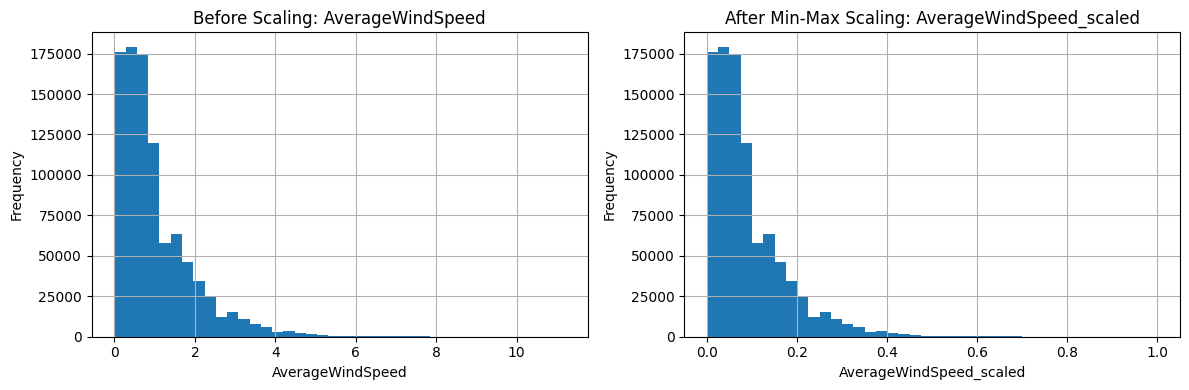

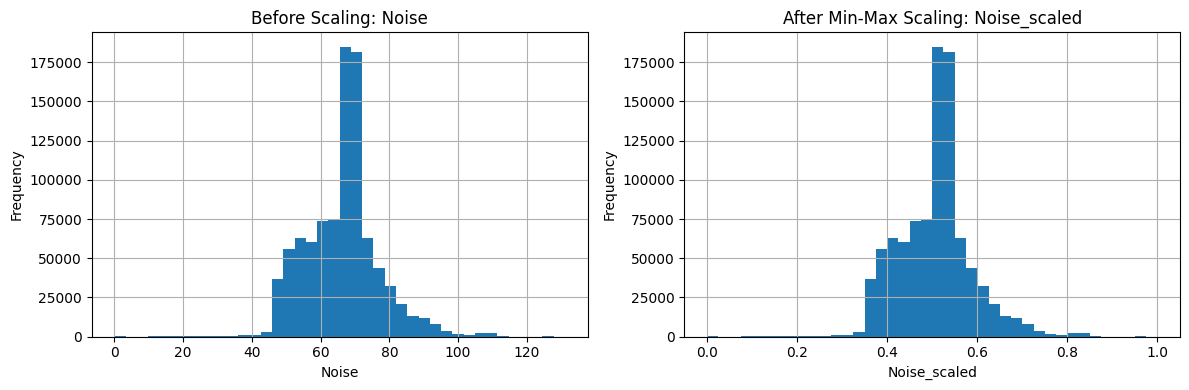

In [70]:
for col in features_to_scale:
    scaled_col = col + "_scaled"
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    data_clean[col].hist(bins=40)
    plt.title(f"Before Scaling: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.subplot(1, 2, 2)
    data_clean[scaled_col].hist(bins=40)
    plt.title(f"After Min-Max Scaling: {scaled_col}")
    plt.xlabel(scaled_col)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

Min-max scaling was applied to `AverageWindSpeed` and `Noise` because they are continuous numerical measurement variables. The original columns were kept, and new scaled columns were added for comparison. Scaling transformed the selected features into a common 0–1 range, which is useful for future machine learning algorithms that are sensitive to differences in feature scale.

The scaling process changes the numerical range of the variables, but it does not change the overall shape of their distributions. Therefore, any skewness or outlier patterns visible before scaling are generally still visible after scaling, only on a different scale.

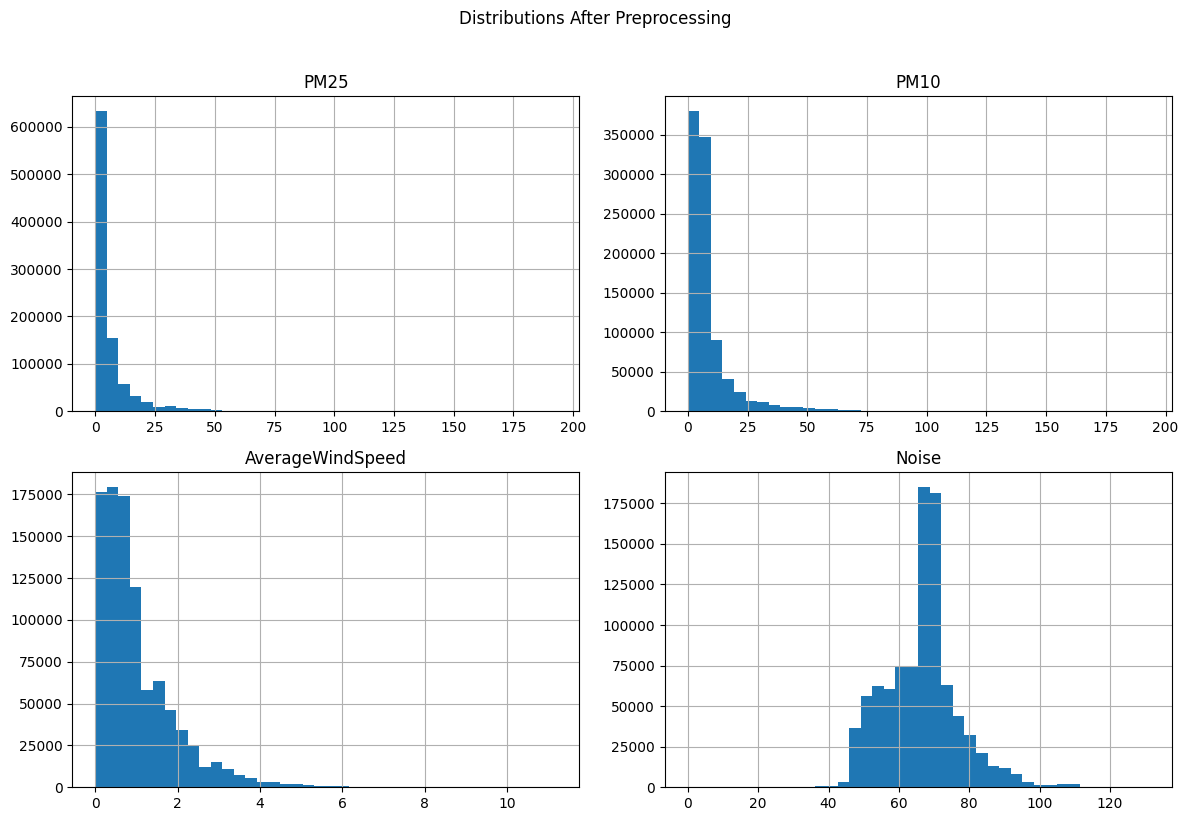

In [71]:
review_cols = ["PM25", "PM10", "AverageWindSpeed", "Noise"]

data_clean[review_cols].hist(bins=40, figsize=(12, 8))
plt.suptitle("Distributions After Preprocessing", y=1.02)
plt.tight_layout()
plt.show()

## Bivariate Analysis

### Correlation Heatmap of Numerical Features

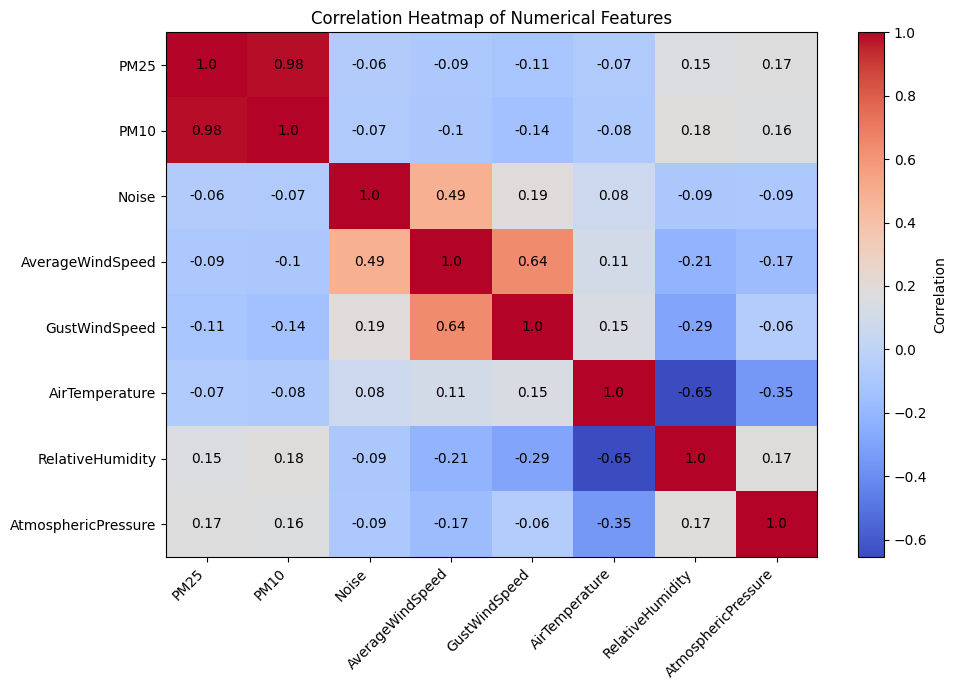

In [72]:
corr_cols = [
    "PM25", "PM10", "Noise",
    "AverageWindSpeed", "GustWindSpeed",
    "AirTemperature", "RelativeHumidity", "AtmosphericPressure"
]

corr_matrix = data_clean[corr_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap of Numerical Features")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

### Relationship Between PM25 and PM10

In [73]:
pm_corr = data_clean[["PM25", "PM10"]].corr()
pm_corr

,PM25,PM10
PM25,1.000000,0.981931
PM10,0.981931,1.000000


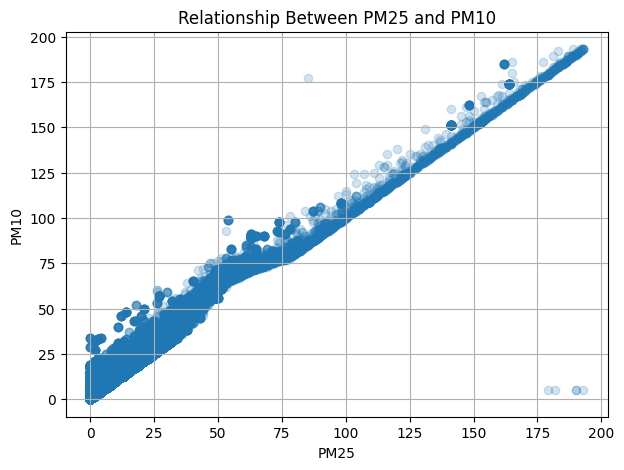

In [74]:
plt.figure(figsize=(7, 5))
plt.scatter(data_clean["PM25"], data_clean["PM10"], alpha=0.2)
plt.xlabel("PM25")
plt.ylabel("PM10")
plt.title("Relationship Between PM25 and PM10")
plt.grid(True)
plt.show()

### Relationship Between Wind Speed and PM Values

In [76]:
wind_pm_cols = ["AverageWindSpeed", "PM25", "PM10"]

data_clean[wind_pm_cols].corr()

,AverageWindSpeed,PM25,PM10
AverageWindSpeed,1.000000,-0.086712,-0.097181
PM25,-0.086712,1.000000,0.981931
PM10,-0.097181,0.981931,1.000000


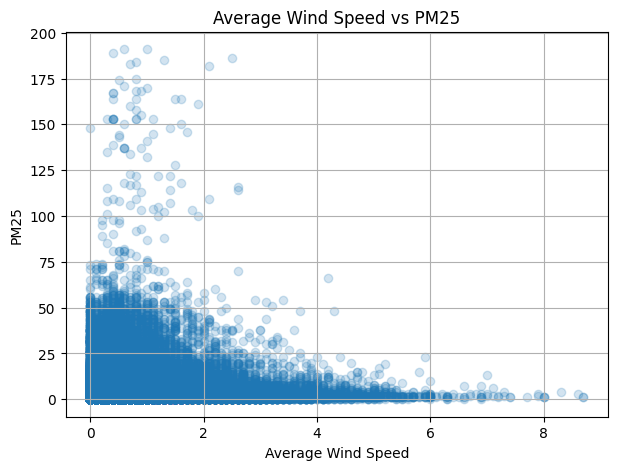

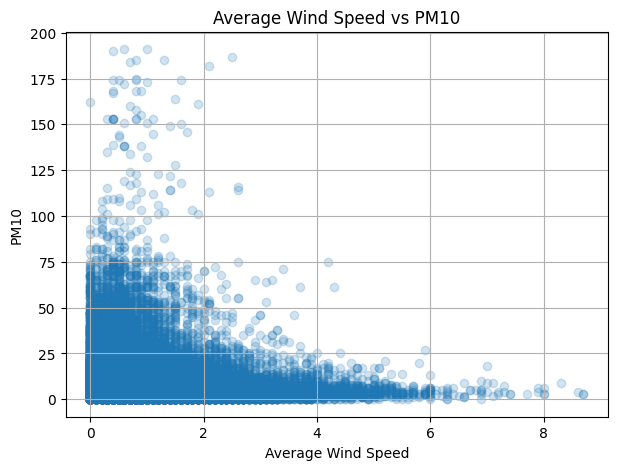

In [77]:
sample_data = data_clean.sample(50000, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(sample_data["AverageWindSpeed"], sample_data["PM25"], alpha=0.2)
plt.xlabel("Average Wind Speed")
plt.ylabel("PM25")
plt.title("Average Wind Speed vs PM25")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(sample_data["AverageWindSpeed"], sample_data["PM10"], alpha=0.2)
plt.xlabel("Average Wind Speed")
plt.ylabel("PM10")
plt.title("Average Wind Speed vs PM10")
plt.grid(True)
plt.show()

In [83]:
wind_pm_summary = data_clean.groupby("WindSpeed_Bin", observed=True)[["PM25", "PM10"]].median()
wind_pm_summary

,PM25,PM10
WindSpeed_Bin,,
"(-0.0112, 1.12]",3.0,5.0
"(1.12, 2.24]",3.0,5.0
"(2.24, 3.36]",2.0,4.0
"(3.36, 4.48]",2.0,4.0
"(4.48, 5.6]",2.0,4.0
"(5.6, 6.72]",1.0,4.0
"(6.72, 7.84]",1.0,4.0
"(7.84, 8.96]",1.5,4.0
"(8.96, 10.08]",1.5,4.0


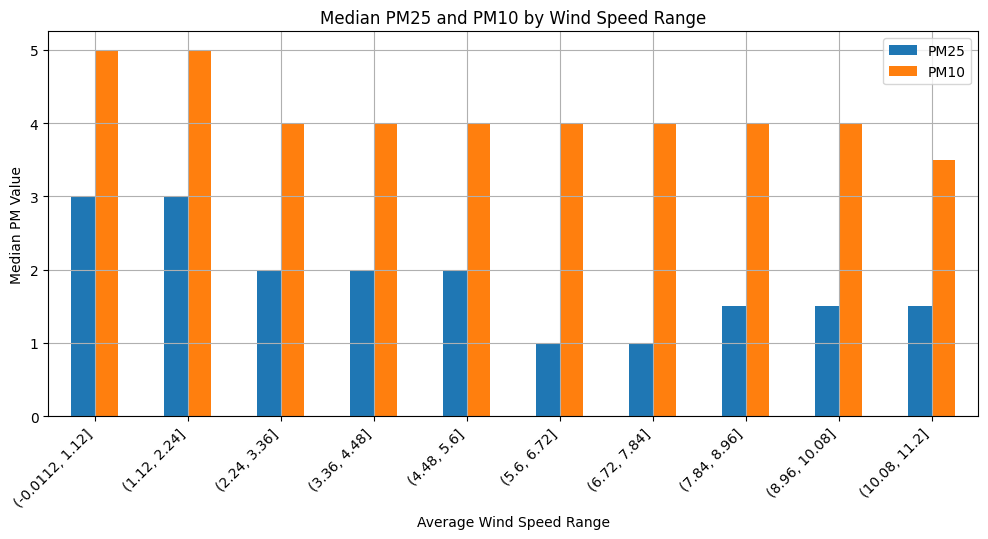

In [79]:
wind_pm_summary.plot(kind="bar", figsize=(12, 5))
plt.title("Median PM25 and PM10 by Wind Speed Range")
plt.xlabel("Average Wind Speed Range")
plt.ylabel("Median PM Value")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

### Weekly Trend Relationship: Wind Speed vs PM25/PM10

In [80]:
ts_data_clean = data_clean.copy()
ts_data_clean["Time"] = pd.to_datetime(ts_data_clean["Time"], errors="coerce")

weekly_trend = (
    ts_data_clean
    .set_index("Time")[["PM25", "PM10", "AverageWindSpeed"]]
    .resample("W")
    .mean()
)

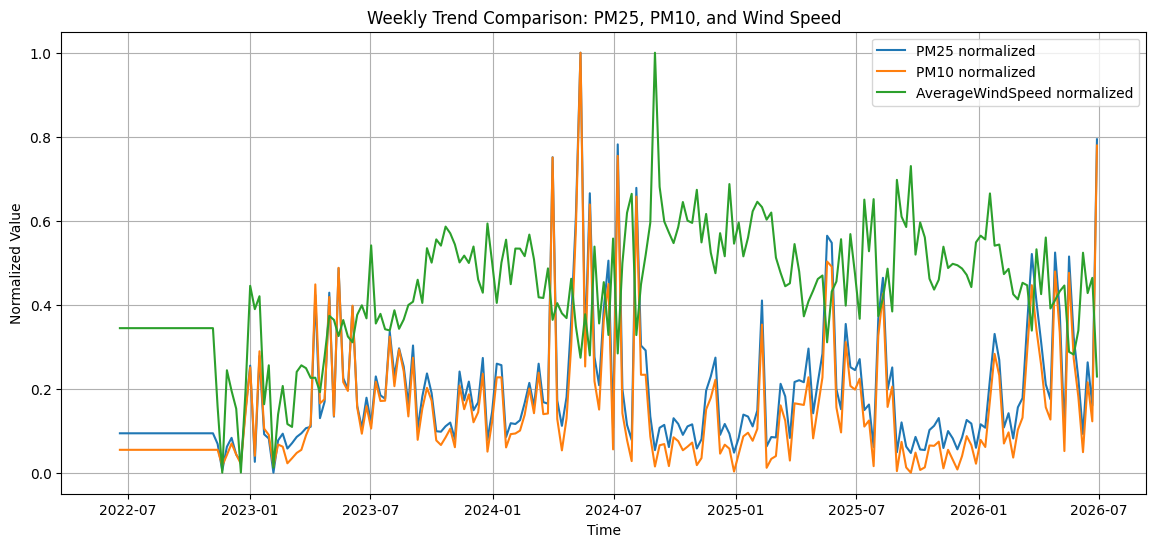

In [81]:
weekly_trend_norm = (weekly_trend - weekly_trend.min()) / (weekly_trend.max() - weekly_trend.min())

plt.figure(figsize=(14, 6))
plt.plot(weekly_trend_norm.index, weekly_trend_norm["PM25"], label="PM25 normalized")
plt.plot(weekly_trend_norm.index, weekly_trend_norm["PM10"], label="PM10 normalized")
plt.plot(weekly_trend_norm.index, weekly_trend_norm["AverageWindSpeed"], label="AverageWindSpeed normalized")

plt.title("Weekly Trend Comparison: PM25, PM10, and Wind Speed")
plt.xlabel("Time")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()

In [82]:
weekly_trend.corr()

,PM25,PM10,AverageWindSpeed
PM25,1.000000,0.992402,-0.16176
PM10,0.992402,1.000000,-0.21680
AverageWindSpeed,-0.161760,-0.216800,1.00000


**Conclusion - 08**

The correlation heatmap shows a very strong positive relationship between `PM25` and `PM10` with a correlation of approximately 0.98. This is also visible in the scatter plot, where both pollutant variables move almost linearly together. This suggests that when PM25 increases, PM10 usually increases as well.

`AverageWindSpeed` has a weak negative correlation with both `PM25` and `PM10` at around -0.09 and -0.10. This means there is no strong linear relationship, but the scatter plots suggest that high PM values are more common when wind speed is low. As wind speed increases, pollutant values generally appear lower and less spread out.

The binned wind speed analysis supports this pattern slightly: median PM values are generally higher in lower wind speed ranges and lower in higher wind speed ranges. However, the pattern is not perfectly smooth, so this should be interpreted cautiously.

The weekly trend comparison shows that PM25 and PM10 move closely together over time, but their relationship with wind speed is **less direct**. Some pollution spikes occur when wind speed is not especially high, suggesting that wind speed alone does not explain pollutant levels. Other factors such as location, wind direction, local activity, traffic, weather conditions, or sensor-specific behaviour may also contribute.

Overall, the bivariate analysis suggests that PM25 and PM10 are strongly related, while wind speed may have a weak inverse relationship with pollutant concentration. This makes sense environmentally because stronger wind may help disperse particles, but the relationship is not strong enough to explain pollution levels on its own.

### Wind Direction, Wind Speed, and Pollutant Levels

In [84]:
direction_pm_summary = (
    data_clean
    .groupby("AverageWindDirection_Category")
    [["PM25", "PM10", "AverageWindSpeed"]]
    .agg(["count", "mean", "median", "max"])
)

direction_pm_summary

PM25                            PM10  \
                                count      mean median    max   count   
AverageWindDirection_Category                                           
E                               80668  6.095775    3.0  164.0   80668   
N                              303392  6.707820    3.0  193.0  303392   
NE                             108842  6.218629    3.0  185.0  108842   
NW                             122141  5.796817    3.0  193.0  122141   
S                              134865  5.402973    3.0  193.0  134865   
SE                              87757  5.379480    3.0  179.0   87757   
SW                              49702  5.327592    2.0  193.0   49702   
W                               53592  4.991902    2.0  193.0   53592   

                                                      AverageWindSpeed  \
                                   mean median    max            count   
AverageWindDirection_Category                                            
E                              8.934460    5.0  185.0            80668   
N                              9.023676    5.0  193.0           303392   
NE                             8.648886    5.0  185.0           108842   
NW                             7.777560    5.0  193.0           122141   
S                              7.460446    5.0  193.0           134865   
SE                             7.984241    5.0  185.0            87757   
SW                             7.071727    4.0  193.0            49702   
W                              7.020264    4.0  193.0            53592   

                                                      
                                   mean median   max  
AverageWindDirection_Category                         
E                              0.981451    0.7  11.1  
N                              0.638539    0.4   9.0  
NE                             0.646244    0.5   7.9  
NW                             1.076778    0.8  10.7  
S                              1.569968    1.3   9.7  
SE                             1.410141    1.1  11.2  
SW                             1.360076    1.2   7.7  
W                              1.008341    0.9  10.1

In [85]:
direction_pm_median = (
    data_clean
    .groupby("AverageWindDirection_Category")
    [["PM25", "PM10", "AverageWindSpeed"]]
    .median()
    .sort_values("PM10", ascending=False)
)

direction_pm_median

,PM25,PM10,AverageWindSpeed
AverageWindDirection_Category,,,
E,3.0,5.0,0.7
N,3.0,5.0,0.4
NE,3.0,5.0,0.5
NW,3.0,5.0,0.8
S,3.0,5.0,1.3
SE,3.0,5.0,1.1
SW,2.0,4.0,1.2
W,2.0,4.0,0.9


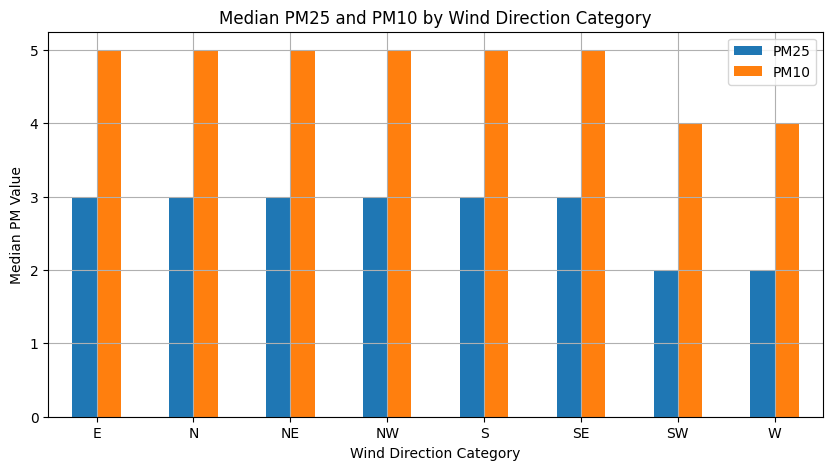

In [86]:
direction_pm_median[["PM25", "PM10"]].plot(kind="bar", figsize=(10, 5))

plt.title("Median PM25 and PM10 by Wind Direction Category")
plt.xlabel("Wind Direction Category")
plt.ylabel("Median PM Value")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [88]:
direction_speed_pm = (
    data_clean
    .groupby(["AverageWindDirection_Category", "WindSpeed_Bin"], observed=True)[["PM25", "PM10"]]
    .median()
    .reset_index()
)

direction_speed_pm

,AverageWindDirection_Category,WindSpeed_Bin,PM25,PM10
0,E,"(-0.0112, 2.24]",3.0,5.0
1,E,"(2.24, 4.48]",2.0,5.0
2,E,"(4.48, 6.72]",1.0,4.0
3,E,"(6.72, 8.96]",1.0,4.0
4,E,"(8.96, 11.2]",1.0,4.0
5,N,"(-0.0112, 2.24]",3.0,5.0
6,N,"(2.24, 4.48]",2.0,4.0
7,N,"(4.48, 6.72]",1.0,3.0
8,N,"(6.72, 8.96]",1.0,4.0
9,N,"(8.96, 11.2]",1.0,3.0


In [90]:
pm10_direction_speed = direction_speed_pm.pivot(
    index="AverageWindDirection_Category",
    columns="WindSpeed_Bin",
    values="PM10"
)

pm10_direction_speed

WindSpeed_Bin,"(-0.0112, 2.24]","(2.24, 4.48]","(4.48, 6.72]","(6.72, 8.96]","(8.96, 11.2]"
AverageWindDirection_Category,,,,,
E,5.0,5.0,4.0,4.0,4.0
N,5.0,4.0,3.0,4.0,3.0
NE,5.0,4.0,2.5,2.0,NaN
NW,5.0,3.0,3.0,3.0,3.0
S,5.0,5.0,5.0,6.0,12.0
SE,5.0,5.0,4.0,4.0,4.0
SW,5.0,3.0,2.0,1.5,NaN
W,4.0,2.0,3.0,4.0,3.5


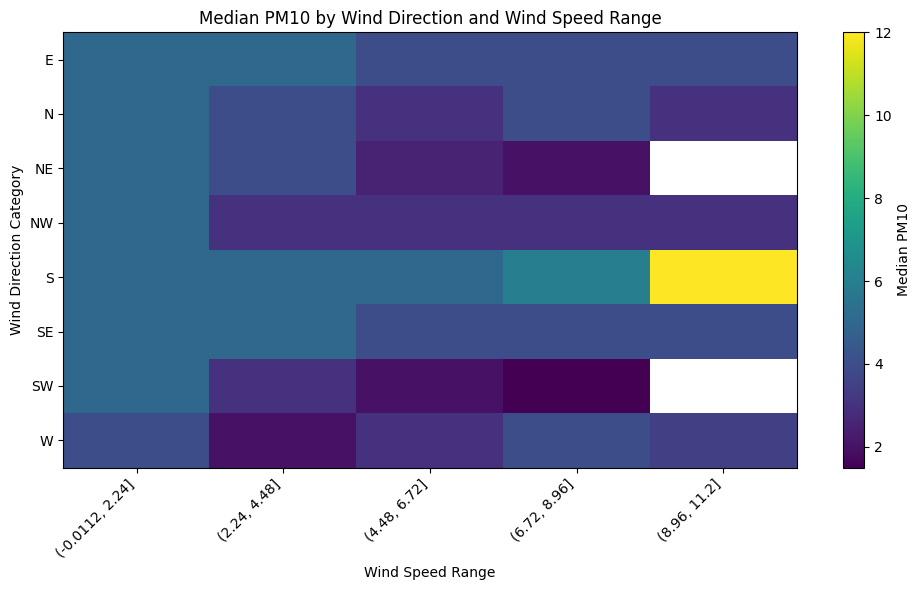

In [91]:
plt.figure(figsize=(10, 6))
plt.imshow(pm10_direction_speed, aspect="auto")
plt.colorbar(label="Median PM10")

plt.xticks(
    range(len(pm10_direction_speed.columns)),
    pm10_direction_speed.columns.astype(str),
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(pm10_direction_speed.index)),
    pm10_direction_speed.index
)

plt.title("Median PM10 by Wind Direction and Wind Speed Range")
plt.xlabel("Wind Speed Range")
plt.ylabel("Wind Direction Category")

plt.tight_layout()
plt.show()

In [92]:
pm10_high_threshold = data_clean["PM10"].quantile(0.95)
pm25_high_threshold = data_clean["PM25"].quantile(0.95)

data_clean["High_PM10"] = data_clean["PM10"] >= pm10_high_threshold
data_clean["High_PM25"] = data_clean["PM25"] >= pm25_high_threshold

In [93]:
high_pm_by_direction = (
    data_clean
    .groupby("AverageWindDirection_Category")
    [["High_PM10", "High_PM25"]]
    .mean()
    .sort_values("High_PM10", ascending=False) * 100
)

high_pm_by_direction

,High_PM10,High_PM25
AverageWindDirection_Category,,
N,6.105632,6.304055
E,6.047007,5.755690
NE,5.731243,5.764319
SE,4.609319,4.583110
NW,4.430945,4.557847
S,3.658473,3.898714
W,3.535976,3.593820
SW,3.189006,3.432457


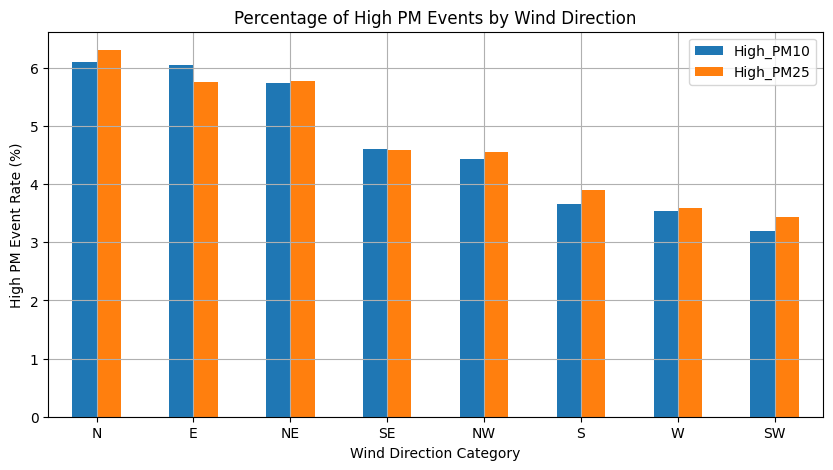

In [94]:
high_pm_by_direction.plot(kind="bar", figsize=(10, 5))

plt.title("Percentage of High PM Events by Wind Direction")
plt.xlabel("Wind Direction Category")
plt.ylabel("High PM Event Rate (%)")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

**conclusion - 09**

The wind direction analysis suggests that PM levels may vary slightly depending on wind direction, but the relationship should be interpreted carefully. The median PM values by direction show only small differences: most directions have median `PM25` around 3 and median `PM10` around 5, while `W` and `SW` are slightly lower. This means that typical pollutant levels are not dramatically different across wind directions.

However, the high pollution event analysis is more informative. Since high PM events were defined using the top 5% of PM values, directions with event rates above 5% are relatively over-represented. `N`, `E`, and `NE` show the highest high-PM event rates, while `W` and `SW` show the lowest. This suggests that high pollution readings are more likely when wind comes from the north, east, or north-east directions.

Wind speed also appears to play a role. Earlier analysis showed a weak negative relationship between wind speed and PM values, suggesting that higher wind speeds may help disperse pollutants. The wind direction summary also shows that some directions with higher PM event rates, such as `N` and `NE`, have relatively low median wind speeds. Therefore, the higher PM events may be related not only to wind direction, but also to lower wind speeds reducing dispersion.

The map shows that sensors are concentrated around central Melbourne, so it is possible that winds from certain directions may carry pollution from nearby urban activity, traffic corridors, or built-up areas. However, this cannot be confirmed from this dataset alone. External geographic and domain information would be needed to explain whether north/east winds are linked to specific pollution sources.

Overall, the analysis suggests a possible association between wind direction, wind speed, and high PM events, but it does not prove causation. Wind direction may be useful as a feature in a future prediction task, especially after being converted into compass categories.

### Windiest Month in 2026

In [95]:
# Ensure Time is in datetime format
data_clean["Time"] = pd.to_datetime(data_clean["Time"], errors="coerce")

# Filter records for 2026
data_2026 = data_clean[data_clean["Time"].dt.year == 2026].copy()

# Extract month name
data_2026["Month"] = data_2026["Time"].dt.month_name()

# Summarise wind speed by month
wind_by_month_2026 = (
    data_2026
    .groupby("Month")["AverageWindSpeed"]
    .agg(["mean", "median", "max", "count"])
    .sort_values("mean", ascending=False)
)

wind_by_month_2026

,mean,median,max,count
Month,,,,
January,1.135325,0.8,10.7,31926
February,0.932499,0.7,9.7,29115
March,0.912779,0.7,10.1,32046
April,0.867888,0.7,7.4,30970
June,0.858276,0.6,7.9,22385
May,0.748013,0.5,8.2,27776


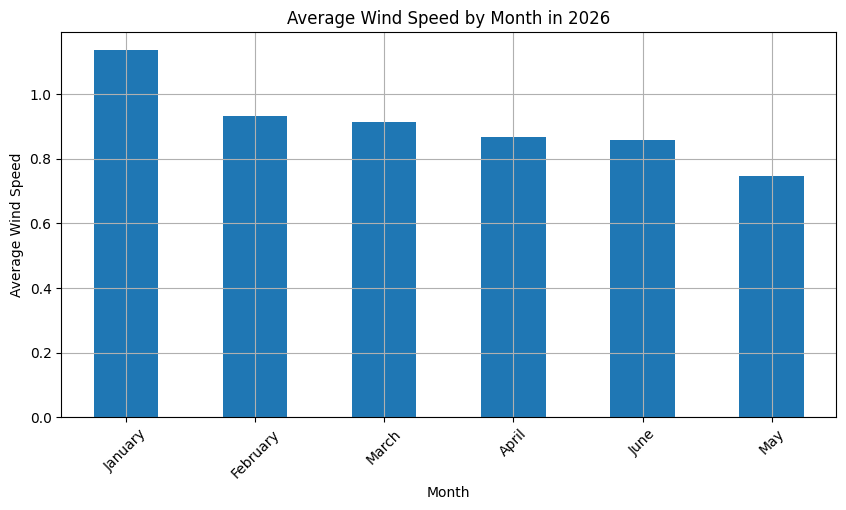

In [96]:
wind_by_month_2026["mean"].plot(kind="bar", figsize=(10, 5))

plt.title("Average Wind Speed by Month in 2026")
plt.xlabel("Month")
plt.ylabel("Average Wind Speed")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The 2026 wind-speed analysis shows that January had the highest average wind speed among the available 2026 months. February and March followed, while May had the lowest average wind speed. The analysis is based on the available records in 2026, so the result should be interpreted in relation to the months present in the dataset rather than a full calendar-year comparison.

### Noisiest Sensor Area in 2026

In [97]:
# Summarise noise by sensor location/area in 2026
noise_by_area_2026 = (
    data_2026
    .groupby("SensorLocation")["Noise"]
    .agg(["mean", "median", "max", "count"])
    .sort_values("mean", ascending=False)
)

noise_by_area_2026

,mean,median,max,count
SensorLocation,,,,
101 Collins St L11 Rooftop,71.310885,69.600000,130.400000,16977
Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station,70.959184,70.500000,117.400000,16937
Enterprize Park - Pole ID: COM1667,70.732661,69.400000,94.600000,16993
1 Treasury Place,70.624472,67.400000,116.500000,28960
Royal Park Asset ID: COM2707,68.000000,68.000000,68.000000,13379
Tram Stop 7B – Melbourne Tennis Centre Precinct – Rod Laver Arena,64.121364,62.100000,100.900000,16991
CH1 rooftop,63.829754,62.900000,89.300000,16942
Tram Stop 7C – Melbourne Tennis Centre Precinct – Rod Laver Arena,63.681685,62.600000,103.200000,16992
Birrarung Marr Park - Pole 1131,53.260372,52.299999,93.300003,17359


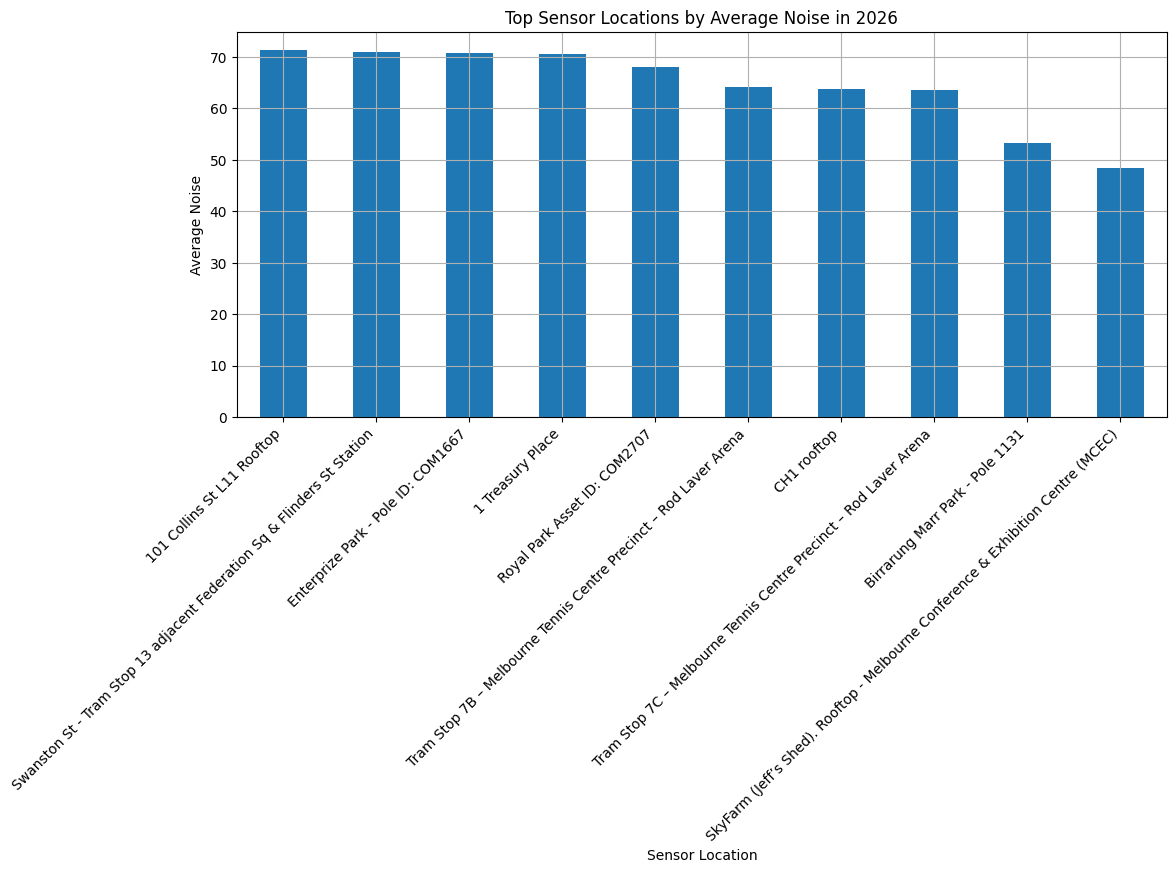

In [98]:
noise_by_area_2026["mean"].head(10).plot(kind="bar", figsize=(12, 5))

plt.title("Top Sensor Locations by Average Noise in 2026")
plt.xlabel("Sensor Location")
plt.ylabel("Average Noise")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.show()

The noise analysis shows that `101 Collins St L11 Rooftop` had the highest average noise level in 2026, followed closely by `Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station`, `Enterprise Park - Pole ID: COM1667`, and `1 Treasury Place`. The differences between the top locations are relatively small, with several locations averaging around 70. This suggests that multiple central urban locations experienced consistently high noise levels, likely due to surrounding activity, traffic, or location-specific conditions.

I am ignoring the correlation between Noise and Pollutants as it is negligible (very small) based on our correlation heatmap table and values

## Summary of Findings

### Final Key Takeaways

The dataset contains repeated time-based observations from a small number of fixed sensor locations in central Melbourne, rather than many different geographic points. Latitude, longitude, time, and sensor identifiers were complete, which made location-based and time-based analysis possible.

Missing values were found mainly in measurement variables. Several missing values occurred in blocks, especially among wind-related variables and among `PM25`, `PM10`, and `Noise`. These missing patterns were also concentrated in specific sensors/locations, suggesting sensor-specific availability issues rather than completely random missingness.

The raw distributions showed strong skewness in `PM25`, `PM10`, and wind speed features. Extreme PM readings, especially values above 3000, were investigated through time-series analysis and found to be concentrated around specific periods and sensor locations. A conservative outlier treatment was applied only to the most extreme PM values, while other environmental readings were retained because they may represent valid real-world conditions.

`PM25` and `PM10` showed a very strong positive relationship, with a correlation of approximately 0.98. This indicates that both particulate matter measures generally move together. Wind speed had a weak negative relationship with PM values, suggesting that higher wind speeds may help reduce or disperse pollutant concentration, although the relationship is not strong enough to explain pollution levels alone.

Wind direction analysis showed that high PM events were slightly more common when wind came from the north, east, and north-east directions. However, this should be interpreted cautiously because the dataset alone cannot confirm pollution sources without additional geographic or domain information.

For 2026, January had the highest average wind speed among the available months. For noise, `101 Collins St L11 Rooftop` had the highest average noise level, although several central locations showed similarly high values.

Overall, the analysis prepared the dataset for the required outputs by:
* identifying missing data issues
* treating selected extreme values
* transforming wind direction
* applying scaling
* and exploring the main relationships between pollutants, wind speed, wind direction, time, and location.